In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load processed data
master_df = pd.read_csv('../data/processed/master_features.csv')

X = master_df.drop(columns=['DESYNPUF_ID', 'DISENGAGED'])
y = master_df['DISENGAGED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train lighter Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Model trained")

Model trained


In [2]:
import shap

explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP done")
print(type(shap_values))

SHAP done
<class 'numpy.ndarray'>


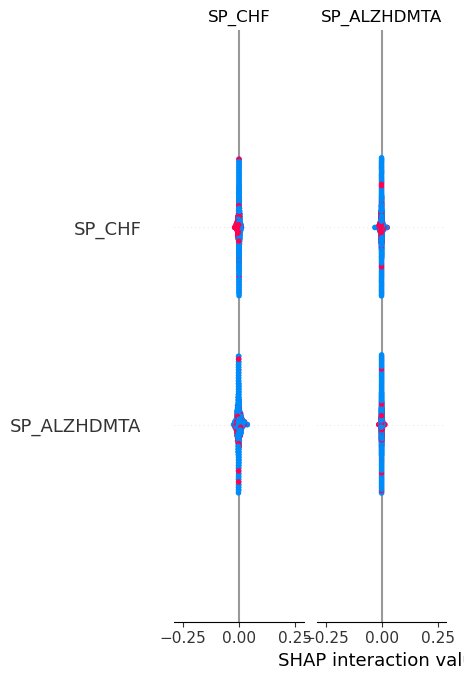

In [3]:
shap.summary_plot(shap_values, X_test_sample, 
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar')

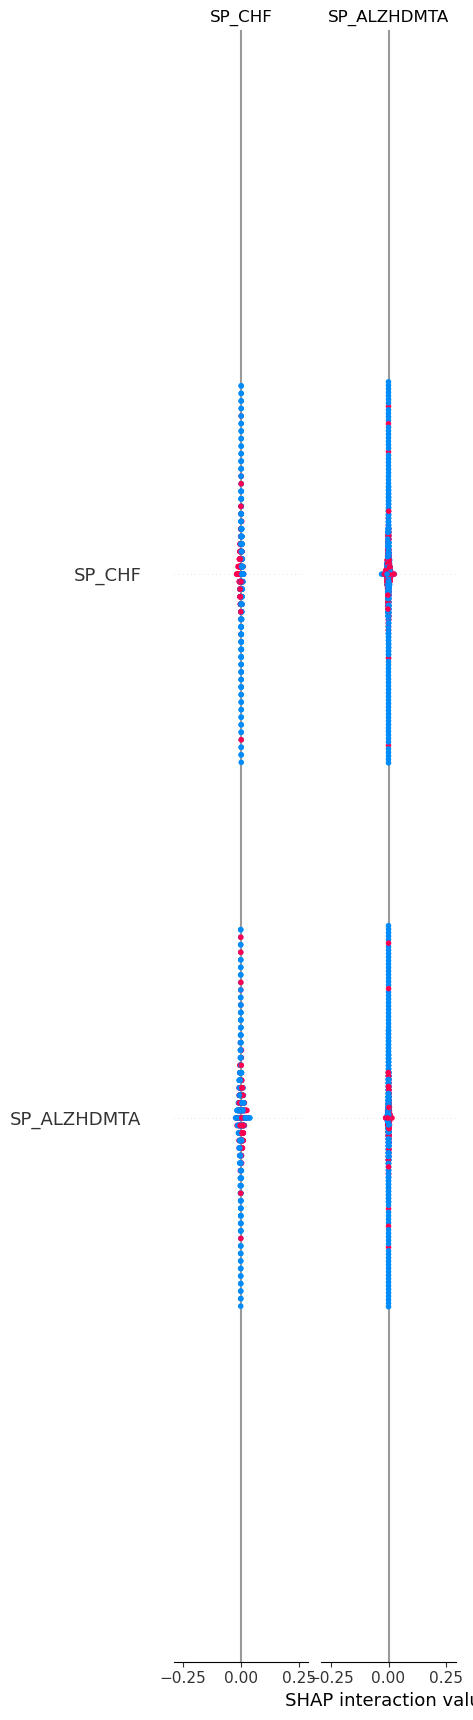

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

# Simple bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_test_sample, 
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar',
                  max_display=20)
plt.tight_layout()
plt.show()

In [5]:
print(shap_values.shape)
print(X_test_sample.shape)

(500, 46, 2)
(500, 46)


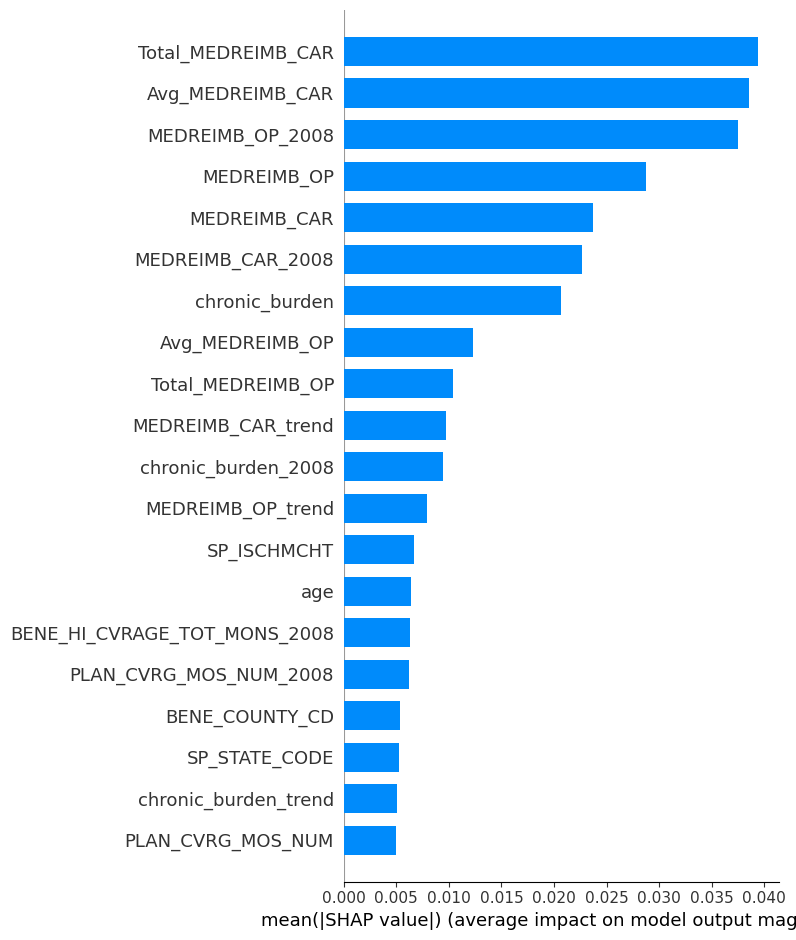

In [7]:
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  feature_names=X_test_sample.columns.tolist(),
                  plot_type='bar',
                  max_display=20)
plt.show()

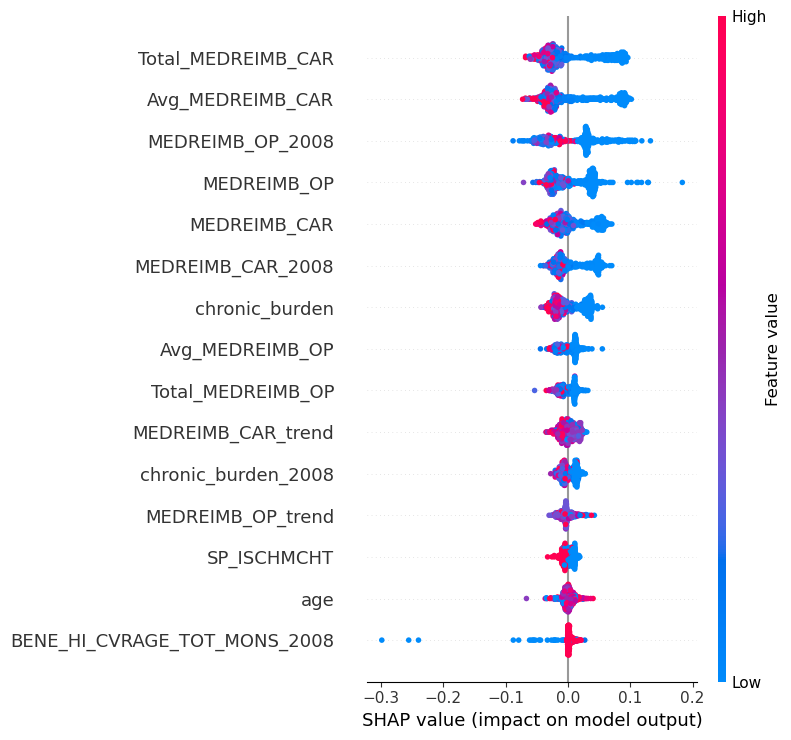

In [8]:
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  feature_names=X_test_sample.columns.tolist(),
                  max_display=15)
plt.show()


THE SHAP VALUES TELL US THAT THE MEMBERS WHO HAVE REDUCED FILLING CLAIMS FOR PHYSICIAN VISITS ARE BEING OUSHED TOWARDS DISENGAGEMENT,